In [20]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
import numpy as np
import matplotlib.pyplot as plt

from src.dataset import XBDDataset
from src.utils import PROJECT_ROOT

In [22]:
PATH = PROJECT_ROOT / ".dataset" / "train"

dataset = XBDDataset(root=PATH, patch_division=True, transform=None)

In [51]:
img, label = dataset[0]
img.shape, label.shape

((512, 512, 3), (512, 512))

In [52]:
np.unique(label)

array([0, 1], dtype=uint8)

In [24]:
def show_sample(dataset, idx, with_label):
    img, label = dataset[idx]
    plt.imshow(img)
    if with_label:
        plt.imshow(label, alpha=0.3)

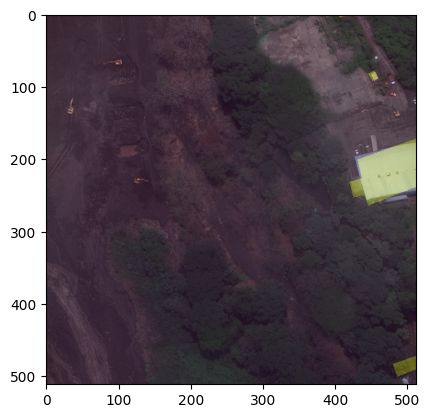

In [27]:
show_sample(dataset, 0, with_label=True)

In [64]:
def plot_sample_images(dataset, n=10):
    columns_n = 5
    rows_n = int(np.ceil(n / columns_n))
    indices = np.random.choice(len(dataset), size=n, replace=False)

    for title, show_mask in [("Original", False), ("With Mask", True)]:
        plt.figure(figsize=(columns_n * 3, rows_n * 3))

        for i, idx in enumerate(indices, 1):
            img, mask = dataset[idx]
            plt.subplot(rows_n, columns_n, i)
            plt.imshow(img.squeeze(), cmap="gray")
            if show_mask:
                plt.imshow(mask.squeeze(), alpha=0.7)
                classes = np.unique(mask)
                plt.title(str(classes), fontsize=5)
            plt.axis("off")

        plt.suptitle(title)
        plt.show()

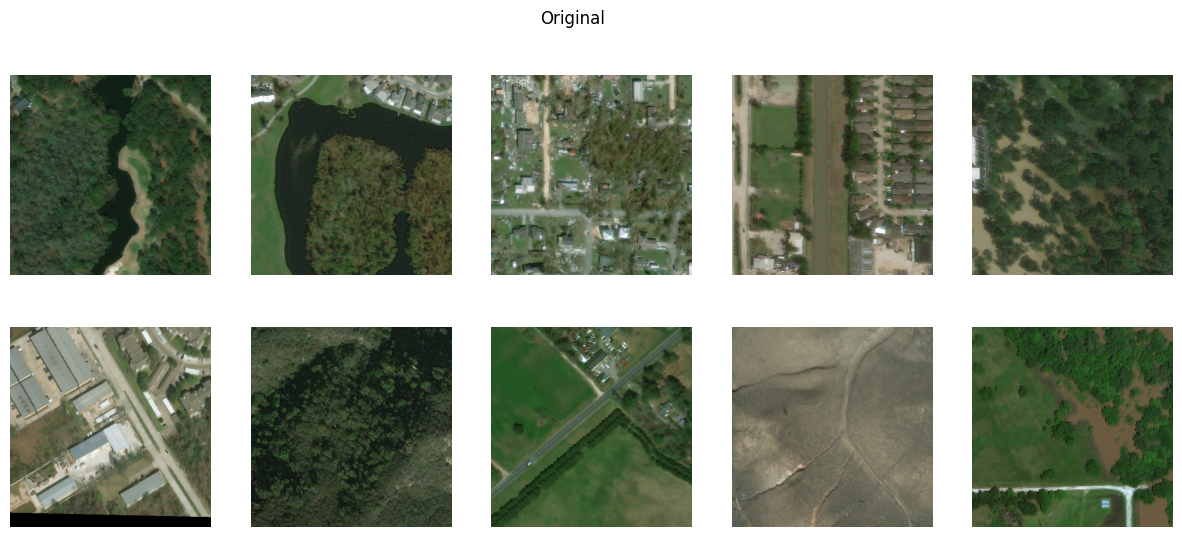

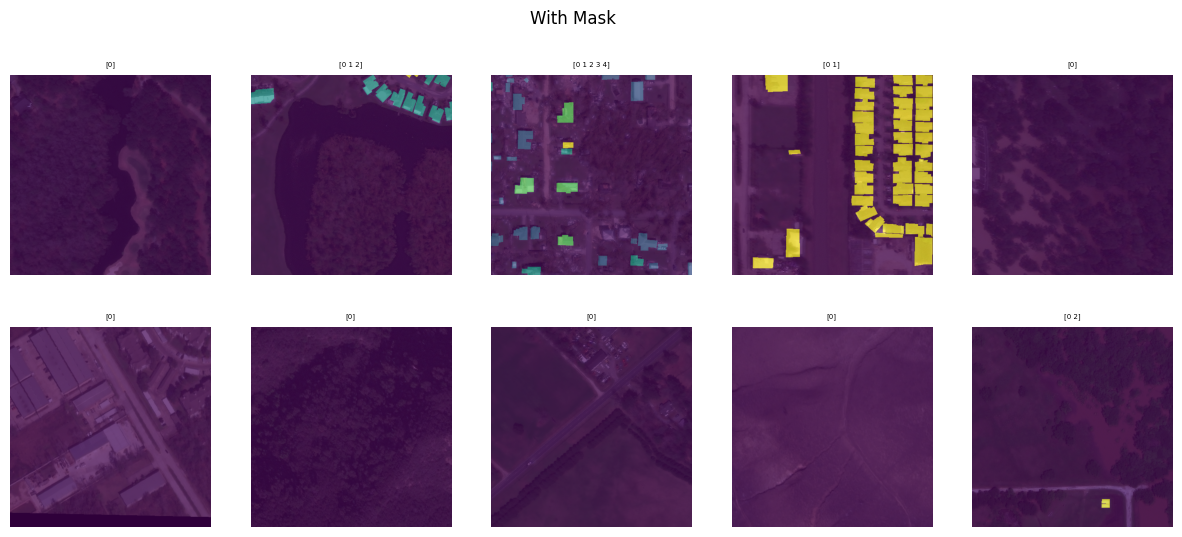

In [65]:
plot_sample_images(dataset)

In [70]:
def plot_class_distribution(dataset):
    class_sample_counts = np.zeros(dataset.NUM_CLASSES, dtype=np.int64)

    for _, mask in dataset:
        for c in np.unique(mask):
            class_sample_counts[c] += 1

    class_names = dataset.get_class_names()
    labels = [class_names[c] for c in range(dataset.NUM_CLASSES)]

    plt.figure(figsize=(8, 4))
    bars = plt.bar(labels, class_sample_counts)
    plt.bar_label(bars, padding=3, fontsize=9)
    plt.title("Samples Containing Each Class")
    plt.ylabel("Number of Samples")
    plt.tight_layout()
    plt.show()

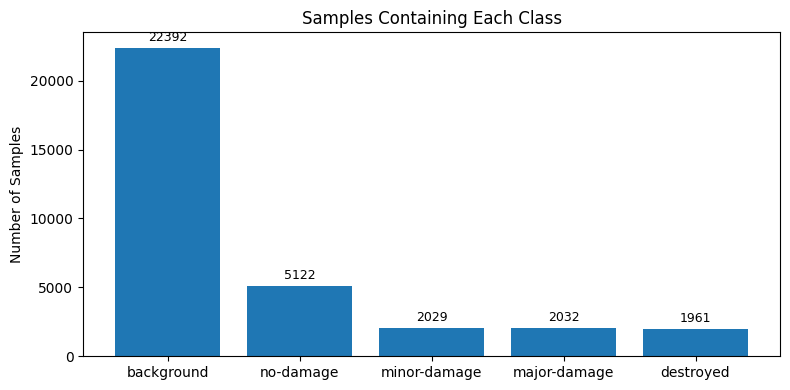

In [71]:
plot_class_distribution(dataset)